In [ ]:
import pandas as pd
import ast
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

df = pd.read_csv('IMDbmovies250.csv', index_col=0)

df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)


df['contentRating'].fillna('Unknown', inplace=True)


X = pd.concat([
    genres_encoded,
    pd.get_dummies(df['contentRating'], prefix='rating'),
    df[['budget', 'grossWorldwide', 'numVotes']]
], axis=1)


y = df['averageRating']

X = X.fillna(X.median())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 10 важных признаков:")
print(importances.head(10))

/tmp/ipython-input-1083942030.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['contentRating'].fillna('Unknown', inplace=True)


R²: 0.3055920631106901
RMSE: 0.18622972372851693

Top 10 важных признаков:
numVotes          0.593548
budget            0.137307
grossWorldwide    0.105893
rating_PG         0.014920
Comedy            0.013857
Adventure         0.012251
rating_R          0.009280
Crime             0.008988
Fantasy           0.008660
Mystery           0.008359
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline


df = pd.read_csv('IMDbmovies250.csv', index_col=0)


df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
mlb = MultiLabelBinarizer()
genres_df = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)


df['num_genres'] = df['genres'].apply(len)


df['contentRating'].fillna('Unknown', inplace=True)
content_rating_dummies = pd.get_dummies(df['contentRating'], prefix='rating')


X_num = df[['budget', 'grossWorldwide', 'numVotes']].copy()
for col in X_num.columns:
    X_num[col] = X_num[col].apply(lambda x: np.log1p(x) if pd.notna(x) and x > 0 else 0)
X_num.fillna(0, inplace=True)


y = df['averageRating'].clip(lower=1.0, upper=10.0)

X = pd.concat([genres_df, content_rating_dummies, X_num, df[['num_genres']]], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 1. Linear Regression
linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# 2. Ridge Regression с GridSearch
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
ridge_params = {'model__alpha': [0.1, 1.0, 10.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

# 3. Gradient Boosting с GridSearch
gb_model = GradientBoostingRegressor(random_state=42)
gb_params = {
    'n_estimators': [100,200],
    'max_depth': [3, 5,7],
    'learning_rate': [0.05, 0.1]
}
gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf', C=10, gamma='scale'))
])

# 5. Random Forest
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)


models = {
    'Linear Regression': linear_pipe,
    'Ridge Regression': best_ridge,
    'Gradient Boosting': best_gb,
    'Support Vector Regression': svr_pipe,
    'Random Forest': rf_model
}


results = {}
feature_importances = {}

for name, model in models.items():

    if name == 'Support Vector Regression' or name == 'Linear Regression' or name == 'Ridge Regression':

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)


    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R²': r2, 'RMSE': rmse}


    if hasattr(model, 'named_steps'):
        inner_model = model.named_steps['model']
    else:
        inner_model = model

    if hasattr(inner_model, 'coef_'):
        coefs = pd.Series(inner_model.coef_, index=X.columns).abs().sort_values(ascending=False)
        feature_importances[name] = coefs.head(5)
    elif hasattr(inner_model, 'feature_importances_'):
        imps = pd.Series(inner_model.feature_importances_, index=X.columns).sort_values(ascending=False)
        feature_importances[name] = imps.head(5)


results_df = pd.DataFrame(results).T
print("Результаты моделей:")
print(results_df.round(4))

print("\nВажные признаки (топ-5 для каждой модели):")
for name, imp in feature_importances.items():
    print(f"\n{name}:")
    print(imp)

/tmp/ipython-input-98046687.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['contentRating'].fillna('Unknown', inplace=True)


Результаты моделей:
                               R²    RMSE
Linear Regression          0.0996  0.2294
Ridge Regression           0.1556  0.2222
Gradient Boosting          0.2348  0.2115
Support Vector Regression  0.2021  0.2160
Random Forest              0.2857  0.2043

Важные признаки (топ-5 для каждой модели):

Linear Regression:
numVotes          0.211806
grossWorldwide    0.083023
budget            0.060642
Drama             0.055545
rating_Unknown    0.054365
dtype: float64

Ridge Regression:
numVotes          0.166725
grossWorldwide    0.060920
Drama             0.048638
rating_Unknown    0.045462
budget            0.044899
dtype: float64

Gradient Boosting:
numVotes          0.623908
budget            0.156689
grossWorldwide    0.092986
num_genres        0.022345
rating_Unknown    0.013325
dtype: float64

Random Forest:
numVotes          0.612776
budget            0.118826
grossWorldwide    0.110318
num_genres        0.018923
rating_Unknown    0.013912
dtype: float64


/tmp/ipython-input-4043624027.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['contentRating'].fillna('Unknown', inplace=True)


Матрица корреляции:
                  budget  grossWorldwide  numVotes  averageRating  \
budget             1.000           0.566     0.635          0.049   
grossWorldwide     0.566           1.000     0.673          0.079   
numVotes           0.635           0.673     1.000          0.365   
averageRating      0.049           0.079     0.365          1.000   
rating_Approved   -0.168          -0.455    -0.307         -0.048   
rating_G           0.078           0.069     0.016         -0.068   
rating_NC-17       0.003          -0.019     0.041         -0.003   
rating_Not Rated  -0.332          -0.283    -0.394         -0.113   
rating_PG          0.061           0.062     0.017         -0.036   
rating_PG-13       0.213           0.279     0.249          0.117   
rating_Passed     -0.281          -0.311    -0.228         -0.095   
rating_R           0.187           0.293     0.360          0.064   
rating_TV-MA       0.018           0.052    -0.109         -0.031   
rating_Unknown

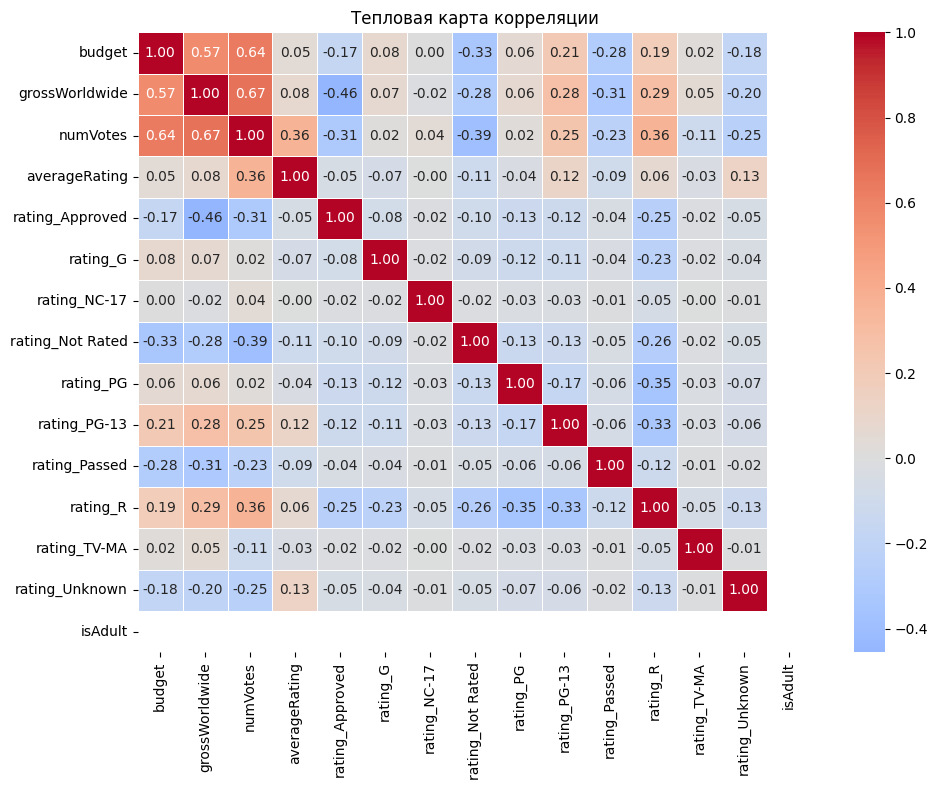

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('IMDbmovies250.csv', index_col=0)


X_num = df[['budget', 'grossWorldwide', 'numVotes','averageRating']].copy()
for col in X_num.columns:
    X_num[col] = X_num[col].apply(lambda x: np.log1p(x) if pd.notna(x) and x > 0 else 0)
X_num.fillna(0, inplace=True)

df['contentRating'].fillna('Unknown', inplace=True)
rating_dummies = pd.get_dummies(df['contentRating'], prefix='rating')

is_adult = df[['isAdult']].astype(int)

X = pd.concat([X_num, rating_dummies, is_adult], axis=1)

corr_matrix = X.corr()


print("Матрица корреляции:")
print(corr_matrix.round(3))


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Тепловая карта корреляции')
plt.tight_layout()
plt.show()

Корреляция между жанрами и числовыми признаками:
           budget  grossWorldwide  numVotes  averageRating
Action     -0.022           0.360     0.159          0.021
Adventure  -0.022           0.451     0.154          0.012
Animation   0.006           0.201    -0.066         -0.046
Biography  -0.030          -0.057    -0.060         -0.096
Comedy      0.095          -0.042    -0.120         -0.165
Crime      -0.051          -0.109     0.191          0.120
Drama       0.029          -0.312    -0.100          0.083
Family     -0.024           0.005    -0.106         -0.059
Fantasy     0.012           0.227     0.133          0.139
Film-Noir  -0.014          -0.069    -0.098         -0.022
History    -0.021          -0.015    -0.060         -0.029
Horror     -0.023          -0.019     0.047          0.030
Music      -0.016          -0.060    -0.007          0.048
Musical    -0.008          -0.039    -0.049         -0.003
Mystery    -0.043          -0.142    -0.062         -0.031
Romance

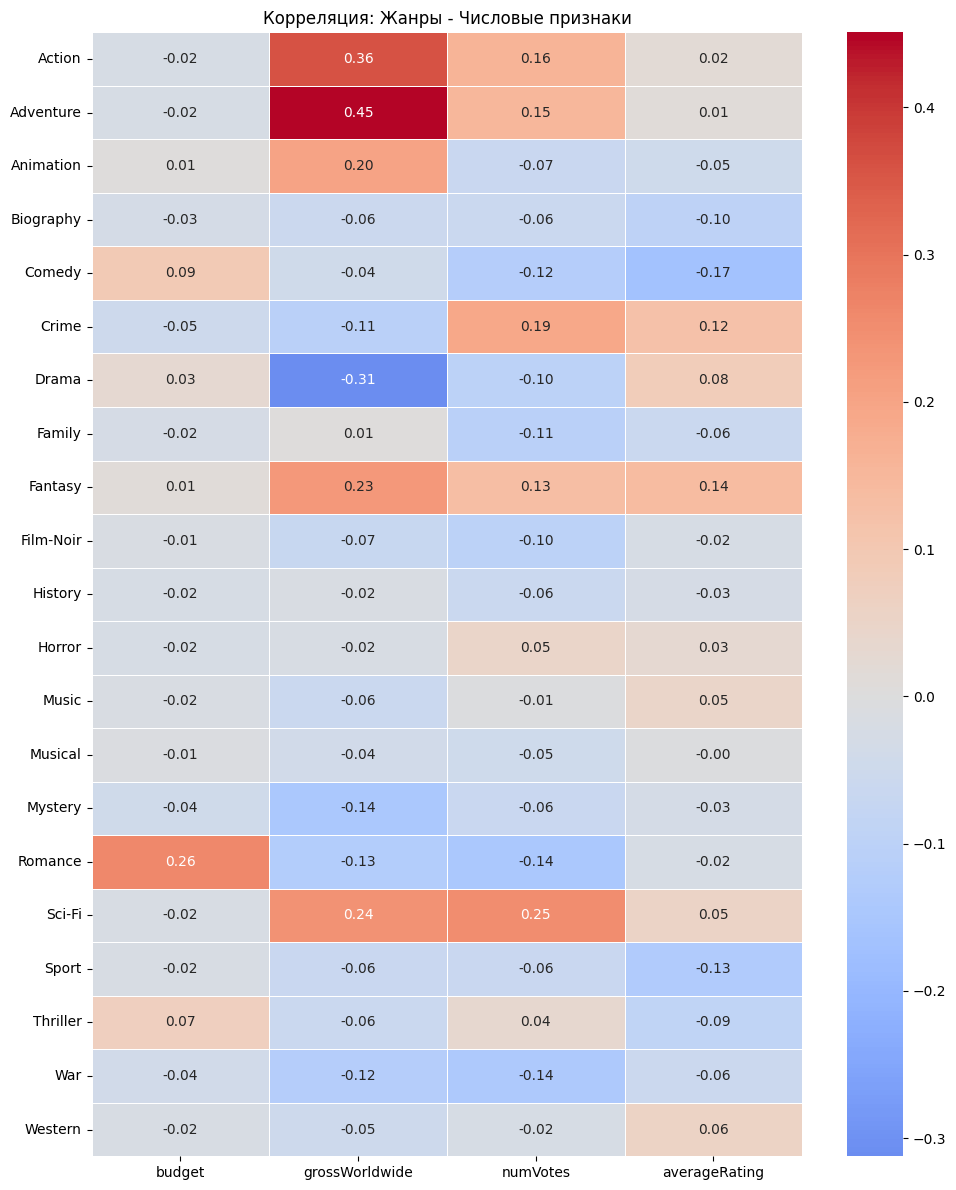

In [ ]:
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('IMDbmovies250.csv', index_col=0)

df['genres'] = df['genres'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres']), columns=mlb.classes_, index=df.index)

numeric_features = df[['budget', 'grossWorldwide', 'numVotes', 'averageRating']].copy()
numeric_features.fillna(numeric_features.median(), inplace=True)

combined = pd.concat([genres_encoded, numeric_features], axis=1)

genre_cols = genres_encoded.columns.tolist()
numeric_cols = numeric_features.columns.tolist()

corr_genre_numeric = combined[genre_cols + numeric_cols].corr().loc[genre_cols, numeric_cols]

print("Корреляция между жанрами и числовыми признаками:")
print(corr_genre_numeric.round(3))

plt.figure(figsize=(10, 12))
sns.heatmap(corr_genre_numeric, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция: Жанры - Числовые признаки')
plt.tight_layout()
plt.show()